In [1]:
print("hello world")

hello world


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

In [10]:
file_path = '/content/NIFTY 50-23-09-2025-to-23-09-2026.csv'
df = pd.read_csv(file_path)
display(df.head())

,SN,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,1,23-Sep-26,23352.15,23466.90,23349.55,23446.8,237608688.0,17215.76
1,2,22-Sep-26,23454.05,23489.00,23285.75,23329.0,244146220.0,19610.73
2,3,21-Sep-26,23330.20,23466.80,23314.80,23414.3,213639227.0,17770.46
3,4,18-Sep-26,23334.70,23389.15,23286.60,23346.4,375346024.0,31510.28
4,5,17-Sep-26,23195.25,23363.55,23193.65,23270.6,259700999.0,18775.30


,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,23352.15,23466.90,23349.55,23446.8,237608688.0,17215.76
1,23454.05,23489.00,23285.75,23329.0,244146220.0,19610.73
2,23330.20,23466.80,23314.80,23414.3,213639227.0,17770.46
3,23334.70,23389.15,23286.60,23346.4,375346024.0,31510.28
4,23195.25,23363.55,23193.65,23270.6,259700999.0,18775.30


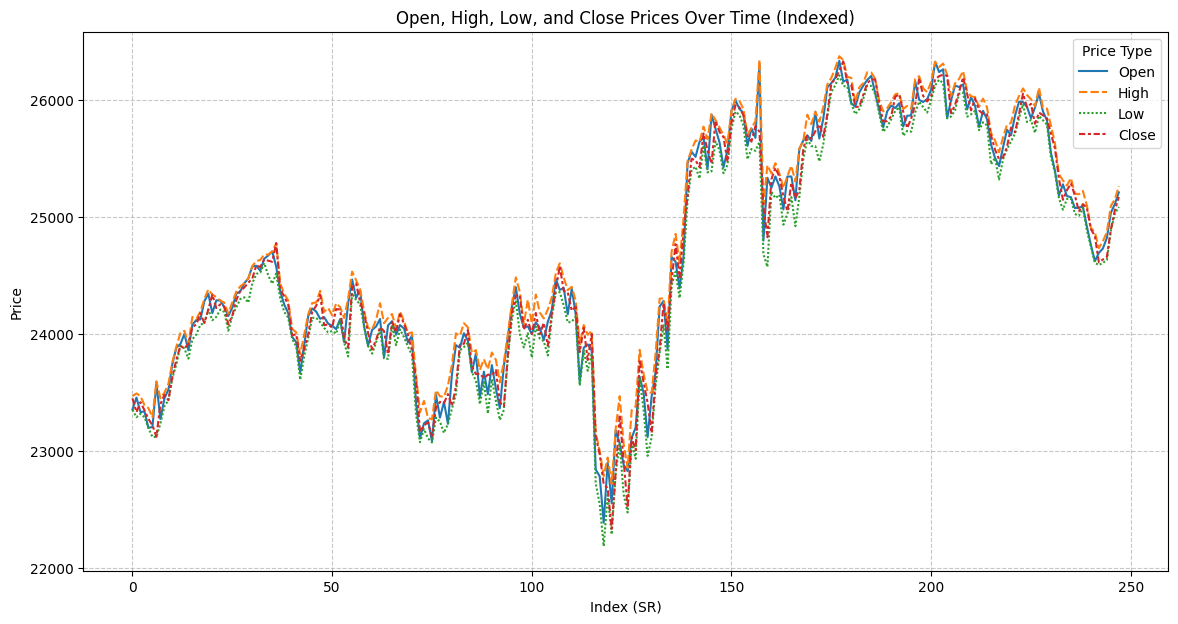

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

plt.figure(figsize=(14, 7))
sns.lineplot(data=df[['Open', 'High', 'Low', 'Close']])
plt.title('Open, High, Low, and Close Prices Over Time (Indexed)')
plt.xlabel('Index (SR)')
plt.ylabel('Price')
plt.legend(title='Price Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [14]:
# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# Rename specified columns
df = df.rename(columns={'Shares Traded': 'shared_traded', 'Turnover (₹ Cr)': 'turnover'})

print('Current DataFrame columns:', df.columns.tolist())

# Convert 'Date' column to datetime objects, coercing errors
df['Date_converted'] = pd.to_datetime(df['Date'], format='%d-%b-%y', errors='coerce')

# Identify rows where date conversion failed
invalid_dates = df[df['Date_converted'].isna()]

# Display rows with invalid date formats
if not invalid_dates.empty:
    print("\nRows with invalid date formats:")
    display(invalid_dates[['Date', 'Date_converted']])
else:
    print("\nNo invalid date formats found.")

# Format the valid dates to 'DD-MM-YYYY'
df['Date_formatted'] = df['Date_converted'].dt.strftime('%d-%m-%Y')

# Display the DataFrame with the new formatted date column and original for comparison
print("\nDataFrame with original and formatted Date columns:")
display(df[['Date', 'Date_formatted']].head())

Current DataFrame columns: ['SN', 'Date', 'Open', 'High', 'Low', 'Close', 'shared_traded', 'turnover']

Rows with invalid date formats:


,Date,Date_converted
36,B38-1,NaT
248,NaN,NaT



DataFrame with original and formatted Date columns:


,Date,Date_formatted
0,23-Sep-26,23-09-2026
1,22-Sep-26,22-09-2026
2,21-Sep-26,21-09-2026
3,18-Sep-26,18-09-2026
4,17-Sep-26,17-09-2026


In [16]:
# Remove rows where 'Date_converted' is NaT (Not a Time)
df_cleaned = df[df['Date_converted'].notna()].copy()

print(f"Original DataFrame rows: {len(df)}")
print(f"Cleaned DataFrame rows: {len(df_cleaned)}")

# Optionally, you can replace the original df with the cleaned one if desired
df = df_cleaned.copy()

display(df.head())

Original DataFrame rows: 249
Cleaned DataFrame rows: 247


,SN,Date,Open,High,Low,Close,shared_traded,turnover,Date_converted,Date_formatted
0,1,23-Sep-26,23352.15,23466.90,23349.55,23446.8,237608688.0,17215.76,2026-09-23,23-09-2026
1,2,22-Sep-26,23454.05,23489.00,23285.75,23329.0,244146220.0,19610.73,2026-09-22,22-09-2026
2,3,21-Sep-26,23330.20,23466.80,23314.80,23414.3,213639227.0,17770.46,2026-09-21,21-09-2026
3,4,18-Sep-26,23334.70,23389.15,23286.60,23346.4,375346024.0,31510.28,2026-09-18,18-09-2026
4,5,17-Sep-26,23195.25,23363.55,23193.65,23270.6,259700999.0,18775.30,2026-09-17,17-09-2026


In [13]:
print(list(df.columns))

['SN', 'Date ', 'Open ', 'High ', 'Low ', 'Close ', 'Shares Traded ', 'Turnover (₹ Cr)']


In [15]:
print(df.sample(5))

      SN       Date      Open      High       Low     Close  shared_traded  \
137  138  04-Mar-26  24388.80  24602.45  24305.40  24480.50    598993881.0   
29    30  12-Aug-26  24472.45  24473.30  24265.95  24435.95    317552958.0   
32    33  07-Aug-26  24538.90  24630.40  24522.75  24570.65    254819435.0   
138  139  02-Mar-26  24659.25  24989.35  24603.50  24865.70    519228821.0   
9     10  09-Sep-26  23522.05  23571.55  23431.50  23431.50    352925400.0   

     turnover Date_converted Date_formatted  
137  47700.19     2026-03-04     04-03-2026  
29   27570.47     2026-08-12     12-08-2026  
32   26131.19     2026-08-07     07-08-2026  
138  41306.37     2026-03-02     02-03-2026  
9    27788.38     2026-09-09     09-09-2026  


In [18]:
# 1. Convert 'Date_converted' to datetime (already done in previous steps) and sort the DataFrame chronologically
# Ensure 'Close' is numeric before calculations
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Drop any rows where 'Close' is NaN after conversion, as these cannot be used for return calculations
df.dropna(subset=['Close'], inplace=True)

df.sort_values(by='Date_converted', inplace=True)
df.reset_index(drop=True, inplace=True)

# 2. Calculate the daily percentage return
# daily_return = (Close_today / Close_previous_day) - 1
df['daily_return'] = df['Close'].pct_change()

# 3. Define a significant-fall event threshold
EVENT_THRESHOLD = -0.02  # -2%

# 4. Create a separate DataFrame called 'events' containing only the significant-fall days
events = df[df['daily_return'] <= EVENT_THRESHOLD].copy()

# 5. The 'events' DataFrame should contain at least: Date, Close, daily_return
# Using 'Date_formatted' for better readability
events = events[['Date_formatted', 'Close', 'daily_return']]

# 6. Print the total number of significant-fall events
print(f"Total number of significant one-day fall events: {len(events)}")

# 7. Display the identified events sorted from the largest fall to the smallest fall
# (largest fall means most negative daily_return)
print("\nSignificant one-day fall events (sorted from largest fall to smallest):")
display(events.sort_values(by='daily_return', ascending=True))

Total number of significant one-day fall events: 6

Significant one-day fall events (sorted from largest fall to smallest):


,Date_formatted,Close,daily_return
121,19-03-2026,23002.15,-0.032621
123,23-03-2026,22512.65,-0.026038
127,30-03-2026,22331.40,-0.021394
193,08-07-2026,23882.05,-0.021175
126,27-03-2026,22819.60,-0.020889
117,13-03-2026,23151.10,-0.020646
